# Text Analytics Coursework

This notebook provides some example code for loading and examining the dataset for task 2. 

In [1]:
#%load_ext autoreload
#%autoreload 2

# Use HuggingFace's datasets library to access the Emotion dataset
from datasets import load_dataset
import numpy as np
import pandas as pd

# Task 2 - EBM-NLP

This dataset is provided at https://github.com/bepnye/EBM-NLP and a copy has been made available in this repository for convenience. The data will need to be unzipped:

In [2]:
import tarfile
import os

# path_tofile = "./ebm_nlp_2_00.tar.gz"
# extract_directory = os.path.dirname(path_tofile)

# if tarfile.is_tarfile(path_tofile):
#     with tarfile.open(path_tofile) as f:
#         f.extractall(path=extract_directory)  # Extract all members from the archive to the current working directory


The data contains text documents that are annotated for mentions of participants, interventions and outcomes (PIO) in medical research. For each entity type, P, I, or O, there is a slightly different set of documents in the training and test set. Most of the documents are identical, but each type has a few extra documents. So, let's deal with each type separately for now.

To load the text documents, we first make a list of the document IDs for one entity type (P, I or O):
根据标签类型和数据划分，找到有哪些带标注的文档 ID，并统计 train/test 各有多少篇

In [3]:
from pathlib import Path

DATA_DIR = Path("./ebm_nlp_2_00")

docs_dir = DATA_DIR / "documents"

def get_doc_ids(split="train", label_type="participants"):
    """ 
    split: 'train' or 'test' 
    """

    if split == "test":
        split = "test/gold"

    train_dir = (
        DATA_DIR
        / "annotations"
        / "aggregated"
        / "hierarchical_labels"
        / label_type  # assuming that the split is the same for all entity types, we can just look at one of them
        / split
    )
    
    doc_ids = [p.stem.split(".")[0] for p in train_dir.glob("*.AGGREGATED.ann")]
    print(doc_ids)
    return sorted(doc_ids)

doc_ids_p = get_doc_ids("train", "participants")
test_doc_ids_p = get_doc_ids("test", "participants")

print(f"Number of documents in train split for participants: {len(doc_ids_p)}")
print(f"Number of documents in test split for participants: {len(test_doc_ids_p)}")


['10036953', '10037531', '10052279', '10071998', '10073522', '10075386', '10077140', '10078672', '10078673', '10080319', '10084579', '10089089', '10091821', '10093945', '10094243', '10097996', '10100592', '10148879', '10155556', '10172265', '10188144', '10190267', '10194485', '10195003', '10197379', '10200837', '10201101', '10203382', '10207709', '10208073', '10209728', '10211492', '10213233', '10213554', '10223244', '10224577', '10225743', '10230191', '10235220', '10337083', '10337433', '10337657', '10337847', '10338217', '10348763', '10352330', '10352397', '10355394', '10356632', '10360656', '10361382', '10361648', '10373718', '10374155', '10379020', '10380161', '10382082', '10382134', '10385063', '10390407', '10402369', '10404444', '10408075', '10410152', '10414756', '10424316', '10429005', '10437192', '10439497', '10439763', '10441604', '10442506', '10443725', '10448447', '10463377', '10463847', '10470636', '10476617', '10482855', '10489959', '10492627', '10499652', '10506815', '10

Now, we can get the annotations for the first entity type:
这一段是在真正读取某篇文档对应的标注文件。
上一段代码只是找到了有哪些 doc_id；这一段则是把这些 doc_id 对应的 .AGGREGATED.ann 标签文件内容读进来。
简而言之：把每篇文档的 token-level 标注文件读进来，形成一个“每篇文档对应一个标签列表”的数据结构。

In [4]:
def load_labels_for_doc(doc_id, label_type="participants", split="train"):
    """
    label_type: 'participants', 'interventions', or 'outcomes'
    split: 'train' or 'test' 
    """
    if split == "test":
        split = "test/gold"

    ann_path = DATA_DIR / "annotations" / "aggregated" / "hierarchical_labels" / label_type / split/ f"{doc_id}.AGGREGATED.ann"
    
    if not ann_path.exists():
        print(ann_path, "does not exist!")
        return None
    
    with open(ann_path, "r", encoding="utf-8") as f:
        labels = [line.strip() for line in f]
    
    return labels

def load_labels(doc_ids, label_type="participants", split="train"):
    labels = []
    for doc_id in doc_ids:
        doc_labels = load_labels_for_doc(doc_id, label_type, split)
        if doc_labels is not None:
            labels.append(doc_labels)
    return labels

participants_labels = load_labels(doc_ids_p, "participants", split="train")

print(f"Length of participants_labels: {len(participants_labels)}")

test_participants_labels = load_labels(test_doc_ids_p, "participants", split="test")
print(f"Length of test_participants_labels: {len(test_participants_labels)}")

sample = 123
print("Document ID:", doc_ids_p[sample])
print(f"Participants label example for doc {doc_ids_p[sample]}:")
print(participants_labels[sample])

Length of participants_labels: 4609
Length of test_participants_labels: 189
Document ID: 10674680
Participants label example for doc 10674680:
['0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '4', '4', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '1', '1', '1', '1', '1', '1', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '3', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '

In [5]:
from itertools import chain
import numpy as np

all_labels = chain(*participants_labels)

# show how many unique labels there are across the dataset 
# 检查有几种标签
print(np.unique(list(all_labels)))

['0' '1' '2' '3' '4']


Let's look at what labels there are for Participants. The code above shows there are four values: 0 corresponds to 'outside' but 1-4 all indicate tokens that form an entity span. Each number is a level in a hierarchy of specificity. To start with let's not worry about this 'hierarchy'. We can instead just turn the labels into simple BIO (Beginning of a span, Inside a span, and Outside a span) tags.
让我们来看看“参与者”有哪些标签。上面的代码显示有四个值：0 对应“外部”，而 1-4 则都表示构成实体跨度（entity span）的标记。每个数字代表特定性层次结构中的一个级别。起初，我们不必在意这个“层次结构”。相反，我们可以将这些标签转换为简单的 BIO 标签（跨度起始、跨度内部和跨度外部）。

In [6]:
def hierarchical_to_bio(tags):
    """
    Convert EBM-NLP hierarchical labels (0–4) to flat BIO tags.

    Parameters
    ----------
    tags : list[int]
        A list of hierarchical labels for a single document.

    Returns
    -------
    list[str]
        BIO tags ("O", "B", "I").
    """

    bio = []
    prev = 0

    for t in tags:
        t = int(t)  # ensure it's an integer
        if t == 0:
            bio.append("O")
        else:
            if prev == 0:
                bio.append("B")
            else:
                bio.append("I")

        prev = t
        

    return bio

def convert_all_labels_to_bio(labels):
    for i, doc_labels in enumerate(labels):
        labels[i] = hierarchical_to_bio(doc_labels)
    return labels

participants_labels = convert_all_labels_to_bio(participants_labels)
test_participants_labels = convert_all_labels_to_bio(test_participants_labels)

all_labels = chain(*participants_labels)

# show how many unique labels there are across the dataset
print(np.unique(list(all_labels)))

['B' 'I' 'O']


So far, we've loaded the document IDs for participants and the corresponding labels. Now, let's load the documents themselves. They are already tokenised so that the labels match up with the tokens:
到目前为止，我们已经加载了参与者的文档 ID 及其对应的标签。现在，让我们加载文档本身。这些文档已经过分词处理，因此标签与分词结果相匹配：

In [7]:
def load_document(doc_id):
    doc_path = DATA_DIR / "documents" / f"{doc_id}.tokens"
    with open(doc_path, "r", encoding="utf-8") as f:
        return [line.strip() for line in f]

def load_documents(doc_ids):
    documents = []
    for doc_id in doc_ids:
        doc = load_document(doc_id)
        documents.append(doc)
    return documents

participants_tokens = load_documents(doc_ids_p)
test_participants_tokens = load_documents(test_doc_ids_p)

# inspect a random element
print("Document ID:", doc_ids_p[sample])
print(f"Tokenised document example for doc {doc_ids_p[sample]}:")
print(participants_tokens[sample])


Document ID: 10674680
Tokenised document example for doc 10674680:
['Assessment', 'of', 'therapeutic', 'response', 'of', 'Plasmodium', 'falciparum', 'to', 'chloroquine', 'and', 'sulfadoxine-pyrimethamine', 'in', 'an', 'area', 'of', 'low', 'malaria', 'transmission', 'in', 'Colombia', '.', 'Although', 'chloroquine', '(', 'CQ', ')', 'resistance', 'was', 'first', 'reported', 'in', 'Colombia', 'in', '1961', 'and', 'sulfadoxine-pyrimethamine', '(', 'SP', ')', 'resistance', 'in', '1981', ',', 'the', 'frequency', 'of', 'treatment', 'failures', 'to', 'these', 'drugs', 'in', 'Colombia', 'is', 'unclear', '.', 'A', 'modified', 'World', 'Health', 'Organization', '14-day', 'in', 'vivo', 'drug', 'efficacy', 'test', 'for', 'uncomplicated', 'Plasmodium', 'falciparum', 'malaria', 'in', 'areas', 'with', 'intense', 'malaria', 'transmission', 'was', 'adapted', 'to', 'reflect', 'the', 'clinical', 'and', 'epidemiologic', 'features', 'of', 'a', 'low-intensity', 'malaria', 'transmission', 'area', 'in', 'the', 

### Interventions

In [8]:
doc_ids_i = get_doc_ids("train", "interventions")
test_doc_ids_i = get_doc_ids("test", "interventions")

print(f"Number of documents in train split for interventions: {len(doc_ids_i)}")
print(f"Number of documents in test split for interventions: {len(test_doc_ids_i)}")

interventions_tokens = load_documents(doc_ids_i)
test_interventions_tokens = load_documents(test_doc_ids_i)

['10036953', '10037531', '10052279', '10071998', '10073522', '10075386', '10077140', '10078672', '10078673', '10080319', '10084579', '10089089', '10091821', '10093945', '10094243', '10097996', '10100592', '10148879', '10155556', '10172265', '10188144', '10190267', '10194485', '10195003', '10197379', '10200837', '10201101', '10203382', '10207709', '10208073', '10209728', '10211492', '10213233', '10213554', '10223244', '10224577', '10225743', '10230191', '10235220', '10337083', '10337433', '10337657', '10337847', '10338217', '10340153', '10348763', '10352330', '10352397', '10355394', '10356632', '10360656', '10361382', '10361648', '10373718', '10374155', '10379020', '10380161', '10382082', '10382134', '10385063', '10390407', '10402369', '10404444', '10408075', '10410152', '10414756', '10424316', '10429005', '10439497', '10439763', '10441604', '10442506', '10443725', '10448447', '10463847', '10470636', '10476617', '10482855', '10489959', '10492627', '10499652', '10506815', '10509459', '10

In [9]:
interventions_labels = load_labels(doc_ids_i, "interventions", split="train")
print(f"Length of interventions_labels: {len(interventions_labels)}")

test_interventions_labels = load_labels(test_doc_ids_i, "interventions", split="test")
print(f"Length of test_interventions_labels: {len(test_interventions_labels)}")

interventions_labels = convert_all_labels_to_bio(interventions_labels)
test_interventions_labels = convert_all_labels_to_bio(test_interventions_labels)

Length of interventions_labels: 4746
Length of test_interventions_labels: 187


### Outcomes

In [10]:
doc_ids_o = get_doc_ids("train", "outcomes")
test_doc_ids_o = get_doc_ids("test", "outcomes")

print(f"Number of documents in train split for outcomes: {len(doc_ids_o)}")
print(f"Number of documents in test split for outcomes: {len(test_doc_ids_o)}")

outcomes_tokens = load_documents(doc_ids_o)
test_outcomes_tokens = load_documents(test_doc_ids_o)

['10036953', '10037531', '10052279', '10071998', '10075386', '10077140', '10078672', '10078673', '10080319', '10084579', '10089089', '10091821', '10093945', '10094243', '10097996', '10100592', '10148879', '10155556', '10172265', '10188144', '10190267', '10194485', '10195003', '10197379', '10200837', '10201101', '10203382', '10207709', '10208073', '10209728', '10211492', '10213233', '10213554', '10223244', '10224577', '10225743', '10230191', '10235220', '10337083', '10337433', '10337657', '10337847', '10338217', '10340153', '10348763', '10352330', '10352397', '10355394', '10356632', '10360656', '10361382', '10361648', '10374155', '10379020', '10380161', '10382082', '10382134', '10385063', '10390407', '10402369', '10404444', '10408075', '10410152', '10414756', '10424316', '10429005', '10439497', '10439763', '10441604', '10442506', '10443725', '10448447', '10463377', '10463847', '10470636', '10476617', '10482855', '10489959', '10492627', '10499652', '10506815', '10509459', '10517189', '10

In [11]:
outcomes_labels = load_labels(doc_ids_o, "outcomes", split="train")
print(f"Length of outcomes_labels: {len(outcomes_labels)}")

test_outcomes_labels = load_labels(test_doc_ids_o, "outcomes", split="test")   
print(f"Length of test_outcomes_labels: {len(test_outcomes_labels)}")

outcomes_labels = convert_all_labels_to_bio(outcomes_labels)
test_outcomes_labels = convert_all_labels_to_bio(test_outcomes_labels)


Length of outcomes_labels: 4681
Length of test_outcomes_labels: 190


In [12]:
print(f"Intersection of train doc IDs across entity types: {len(set(doc_ids_p) & set(doc_ids_i) & set(doc_ids_o))}")
print(f"Intersection of test doc IDs across entity types: {len(set(test_doc_ids_p) & set(test_doc_ids_i) & set(test_doc_ids_o))}")
print(f"Documents that are different across entity types in train split: {len((set(doc_ids_p) | set(doc_ids_i) | set(doc_ids_o)) - (set(doc_ids_p) & set(doc_ids_i) & set(doc_ids_o)))}")
print(f"Documents that are different across entity types in test split: {len((set(test_doc_ids_p) | set(test_doc_ids_i) | set(test_doc_ids_o)) - (set(test_doc_ids_p) & set(test_doc_ids_i) & set(test_doc_ids_o)))}")


print(f"Test examples of the participants type that are in other entity types' training splits: {set(test_doc_ids_p) & (set(doc_ids_i) | set(doc_ids_o))}")
print(f"Test examples of the interventions type that are in other entity types' training splits: {set(test_doc_ids_i) & (set(doc_ids_p) | set(doc_ids_o))}")
print(f"Test examples of the outcomes type that are in other entity types' training splits: {set(test_doc_ids_o) & (set(doc_ids_p) | set(doc_ids_i))}")

Intersection of train doc IDs across entity types: 4457
Intersection of test doc IDs across entity types: 184
Documents that are different across entity types in train split: 344
Documents that are different across entity types in test split: 7
Test examples of the participants type that are in other entity types' training splits: set()
Test examples of the interventions type that are in other entity types' training splits: set()
Test examples of the outcomes type that are in other entity types' training splits: set()


Task2 Part1

In [13]:
def load_tokens_for_doc(doc_id):
    token_path = docs_dir / f"{doc_id}.tokens"
    
    if not token_path.exists():
        print(token_path, "does not exist!")
        return None
    
    with open(token_path, "r", encoding="utf-8") as f:
        tokens = [line.strip() for line in f]
    
    return tokens

sample = 222
sample_doc_id = doc_ids_p[sample]

sample_tokens = load_tokens_for_doc(sample_doc_id)
print("Doc ID:", sample_doc_id)
print("Number of tokens:", len(sample_tokens))
print(sample_tokens[:50])

print("Tokens:", len(sample_tokens))
print("Labels:", len(participants_labels[sample]))

Doc ID: 11069570
Number of tokens: 356
['Probiotics', 'in', 'the', 'management', 'of', 'atopic', 'eczema', '.', 'BACKGROUND', 'Over', 'the', 'last', 'two', 'decades', 'the', 'incidence', 'of', 'allergic', 'diseases', 'has', 'increased', 'in', 'industrialized', 'countries', ',', 'and', 'consequently', 'new', 'approaches', 'have', 'to', 'be', 'explored', '.', 'OBJECTIVE', 'The', 'potential', 'of', 'probiotics', 'to', 'control', 'allergic', 'inflammation', 'at', 'an', 'early', 'age', 'was', 'assessed', 'in']
Tokens: 356
Labels: 356


In [14]:
for tok, lab in list(zip(sample_tokens, participants_labels[sample]))[:50]:
    print(tok, lab)

Probiotics O
in O
the O
management O
of O
atopic B
eczema I
. I
BACKGROUND O
Over O
the O
last O
two O
decades O
the O
incidence O
of O
allergic O
diseases O
has O
increased O
in O
industrialized O
countries O
, O
and O
consequently O
new O
approaches O
have O
to O
be O
explored O
. O
OBJECTIVE O
The O
potential O
of O
probiotics O
to O
control O
allergic B
inflammation I
at I
an I
early I
age I
was O
assessed O
in O


In [15]:
def tokens_to_text(tokens):
    return " ".join(tokens)

sample_text = tokens_to_text(sample_tokens)
print(sample_text[:1000])

Probiotics in the management of atopic eczema . BACKGROUND Over the last two decades the incidence of allergic diseases has increased in industrialized countries , and consequently new approaches have to be explored . OBJECTIVE The potential of probiotics to control allergic inflammation at an early age was assessed in a randomized double-blind placebo-controlled study . METHODS A total of 27 infants , mean age 4.6 months , who manifested atopic eczema during exclusive breast-feeding and who have had no exposure to any infant or substitute formula were weaned to probiotic-supplemented , Bifidobacterium lactis Bb-12 or Lactobacillus strain GG ( ATCC 53103 ) , extensively hydrolysed whey formulas or to the same formula without probiotics . The extent and severity of atopic eczema , the growth and nutrition of infants , and concentrations of circulating cytokines/chemokines and soluble cell surface adhesion molecules in serum and methyl-histamine and eosinophilic protein X in urine were d

In [16]:
import nltk
from nltk.tokenize import sent_tokenize

def split_into_sentences(tokens):
    text = " ".join(tokens)
    sentences = sent_tokenize(text)
    return sentences

sample_sentences = split_into_sentences(sample_tokens)
print("Number of sentences:", len(sample_sentences))
for i, s in enumerate(sample_sentences[:5]):
    print(f"[{i}] {s}")

Number of sentences: 12
[0] Probiotics in the management of atopic eczema .
[1] BACKGROUND Over the last two decades the incidence of allergic diseases has increased in industrialized countries , and consequently new approaches have to be explored .
[2] OBJECTIVE The potential of probiotics to control allergic inflammation at an early age was assessed in a randomized double-blind placebo-controlled study .
[3] METHODS A total of 27 infants , mean age 4.6 months , who manifested atopic eczema during exclusive breast-feeding and who have had no exposure to any infant or substitute formula were weaned to probiotic-supplemented , Bifidobacterium lactis Bb-12 or Lactobacillus strain GG ( ATCC 53103 ) , extensively hydrolysed whey formulas or to the same formula without probiotics .
[4] The extent and severity of atopic eczema , the growth and nutrition of infants , and concentrations of circulating cytokines/chemokines and soluble cell surface adhesion molecules in serum and methyl-histamin

现在的标签是 token-level，而你要聚类的是 sentence-level。
所以必须把 token 标签聚合成句子标签。

最简单可行的方法是：
先把 token 拼成完整文本
再按句子切分
再想办法把每句话对应回原来的 token 范围
看这句话里哪种标签最多
用多数标签作为这句的 gold label

但为了先跑起来，这里做一个较简单版本：
只先做单一label_type 的探索，例如 participants。
如此可以先回答：
participants 信息的句子会不会自然聚在一起？
也就是说，现在不一定要一步做到 P/I/O 同时分开。
可以先对一个字段做：
如果一句话里包含较多 participants 标签 token，就标为 participants
否则标为 other
这样更容易先跑通。

思路是：

按 token 中的句号、问号、感叹号做粗略句子切分
同时把对应 token labels 分到同一句里
然后给这句一个标签

In [17]:
#基于token的切分函数
def split_tokens_into_sentences(tokens, labels):
    sentences = []
    current_tokens = []
    current_labels = []
    
    end_punct = {".", "!", "?"}
    
    for tok, lab in zip(tokens, labels):
        current_tokens.append(tok)
        current_labels.append(lab)
        
        if tok in end_punct:
            sentences.append((current_tokens, current_labels))
            current_tokens = []
            current_labels = []
    
    if current_tokens:
        sentences.append((current_tokens, current_labels))
    
    return sentences

然后定义一个函数，把一句话的 token labels 变成句子标签。
前面看到过原始标签可能有多个值，比如 0,1,2,3,4。通常 0 往往表示非该类，其余表示属于该类的不同层级/边界。
所以先做一个简化判断

In [18]:
from collections import Counter
def assign_sentence_label(token_labels, positive_label_values=None):
    if positive_label_values is None:
        positive_label_values = {"B", "I"}
    
    pos_count = sum(l in positive_label_values for l in token_labels)
    total = len(token_labels)
    
    if total == 0:
        return "other"
    
    # 先用最宽松的规则，方便跑通流程
    if pos_count >= 2:
        return "participants"
    else:
        return "other"

In [19]:
sample_sentences_tok = split_tokens_into_sentences(sample_tokens, participants_labels[sample])

for sent_toks, sent_labs in sample_sentences_tok[:5]:
    sent_text = " ".join(sent_toks)
    sent_label = assign_sentence_label(sent_labs)
    print(sent_label, ":", sent_text)

participants : Probiotics in the management of atopic eczema .
other : BACKGROUND Over the last two decades the incidence of allergic diseases has increased in industrialized countries , and consequently new approaches have to be explored .
participants : OBJECTIVE The potential of probiotics to control allergic inflammation at an early age was assessed in a randomized double-blind placebo-controlled study .
other : METHODS A total of 27 infants , mean age 4.6 months , who manifested atopic eczema during exclusive breast-feeding and who have had no exposure to any infant or substitute formula were weaned to probiotic-supplemented , Bifidobacterium lactis Bb-12 or Lactobacillus strain GG ( ATCC 53103 ) , extensively hydrolysed whey formulas or to the same formula without probiotics .
other : The extent and severity of atopic eczema , the growth and nutrition of infants , and concentrations of circulating cytokines/chemokines and soluble cell surface adhesion molecules in serum and methy

把所有文档整理成 sentence-level 数据表（整合成基础表）

In [20]:
import pandas as pd

rows = []

for doc_id, doc_labels in zip(doc_ids_p, participants_labels):
    tokens = load_tokens_for_doc(doc_id)
    if tokens is None:
        continue
    
    if len(tokens) != len(doc_labels):
        print(f"Length mismatch for {doc_id}: tokens={len(tokens)}, labels={len(doc_labels)}")
        continue
    
    sentence_units = split_tokens_into_sentences(tokens, doc_labels)
    
    for sent_toks, sent_labs in sentence_units:
        sent_text = " ".join(sent_toks).strip()
        if not sent_text:
            continue
        
        gold_label = assign_sentence_label(sent_labs)
        
        rows.append({
            "doc_id": doc_id,
            "sentence_text": sent_text,
            "gold_label": gold_label
        })

df_sent = pd.DataFrame(rows)
print(df_sent.head())
print(df_sent["gold_label"].value_counts())
print("Number of sentences:", len(df_sent))

     doc_id                                      sentence_text    gold_label
0  10036953  [ Triple therapy regimens involving H2 blockad...         other
1  10036953  Comparison of ranitidine and lansoprazole in s...         other
2  10036953  To evaluate the efficacy and safety of two 1-w...  participants
3  10036953  The drug combination and administration period...         other
4  10036953  The ranitidine group received RNT 300 mg , CAM...         other
gold_label
other           40262
participants     9186
Name: count, dtype: int64
Number of sentences: 49448


算句子 embedding

In [21]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer("all-MiniLM-L6-v2")
embeddings = model.encode(df_sent["sentence_text"].tolist(), show_progress_bar=True)

X = embeddings
print(X.shape)

Batches:   0%|          | 0/1546 [00:00<?, ?it/s]

(49448, 384)


K-means

In [22]:
from sklearn.cluster import KMeans

k = 2   # 因为现在先做 participants vs other
kmeans = KMeans(n_clusters=k, random_state=2816084, n_init=10)
df_sent["cluster_kmeans"] = kmeans.fit_predict(X)

#每个 cluster 里 gold label 的组成
cluster_summary = pd.crosstab(df_sent["cluster_kmeans"], df_sent["gold_label"], normalize="index")
print(cluster_summary)

gold_label         other  participants
cluster_kmeans                        
0               0.812901      0.187099
1               0.816468      0.183532


In [23]:
for k in [2, 3, 4, 5]:
    kmeans = KMeans(n_clusters=k, random_state=2816084, n_init=10)
    df_sent[f"cluster_kmeans_{k}"] = kmeans.fit_predict(X)
    
    summary = pd.crosstab(
        df_sent[f"cluster_kmeans_{k}"],
        df_sent["gold_label"],
        normalize="index"
    )
    print(f"\n===== k = {k} =====")
    print(summary)


===== k = 2 =====
gold_label           other  participants
cluster_kmeans_2                        
0                 0.812678      0.187322
1                 0.816833      0.183167

===== k = 3 =====
gold_label           other  participants
cluster_kmeans_3                        
0                 0.790242      0.209758
1                 0.847089      0.152911
2                 0.797006      0.202994

===== k = 4 =====
gold_label           other  participants
cluster_kmeans_4                        
0                 0.787407      0.212593
1                 0.796479      0.203521
2                 0.883359      0.116641
3                 0.787541      0.212459

===== k = 5 =====
gold_label           other  participants
cluster_kmeans_5                        
0                 0.801513      0.198487
1                 0.710159      0.289841
2                 0.848822      0.151178
3                 0.876747      0.123253
4                 0.775644      0.224356


HAC

In [24]:
from sklearn.cluster import AgglomerativeClustering

hac = AgglomerativeClustering(n_clusters=2)
df_sent["cluster_hac"] = hac.fit_predict(X)

hac_summary = pd.crosstab(
    df_sent["cluster_hac"],
    df_sent["gold_label"],
    normalize="index"
)
print(hac_summary)

gold_label      other  participants
cluster_hac                        
0            0.848447      0.151553
1            0.795301      0.204699


开始PCA画图

In [25]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X)

df_sent["pca1"] = X_2d[:, 0]
df_sent["pca2"] = X_2d[:, 1]

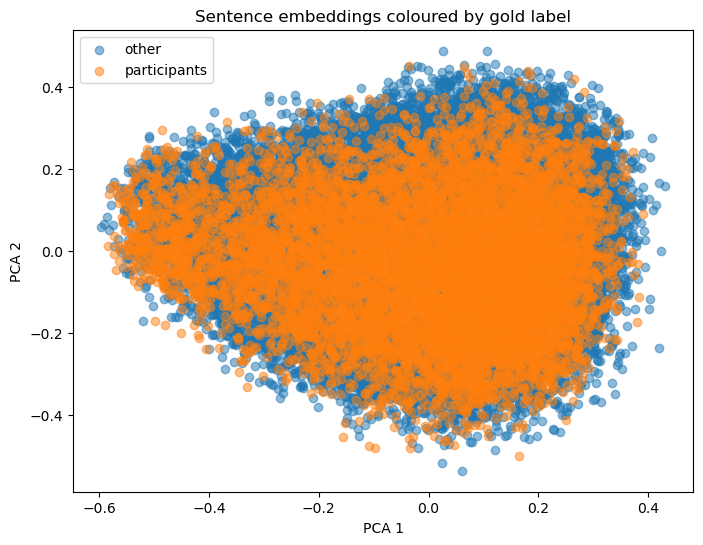

In [26]:
#按Gold label画图
plt.figure(figsize=(8,6))
for lab in df_sent["gold_label"].unique():
    subset = df_sent[df_sent["gold_label"] == lab]
    plt.scatter(subset["pca1"], subset["pca2"], label=lab, alpha=0.5)
plt.legend()
plt.title("Sentence embeddings coloured by gold label")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()

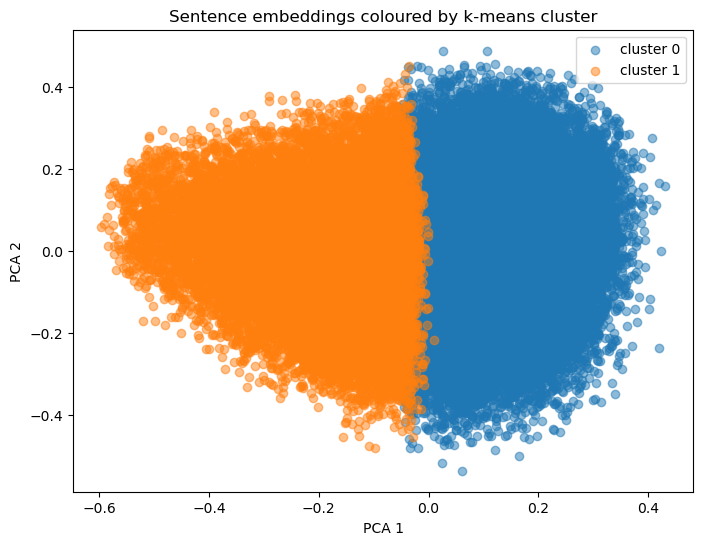

In [27]:
#按Cluster画图
plt.figure(figsize=(8,6))
for c in sorted(df_sent["cluster_kmeans"].unique()):
    subset = df_sent[df_sent["cluster_kmeans"] == c]
    plt.scatter(subset["pca1"], subset["pca2"], label=f"cluster {c}", alpha=0.5)
plt.legend()
plt.title("Sentence embeddings coloured by k-means cluster")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()

In [30]:
print(df_sent["gold_label"].value_counts())

all_labels = list(chain(*participants_labels))
print(np.unique(all_labels))

print(type(participants_labels[0][0]))
print(participants_labels[0][:20])

gold_label
other           40262
participants     9186
Name: count, dtype: int64
['B' 'I' 'O']
<class 'str'>
['O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O']


In [31]:
sample = 123
sample_tokens = load_tokens_for_doc(doc_ids_p[sample])
sample_labels = participants_labels[sample]

sentence_units = split_tokens_into_sentences(sample_tokens, sample_labels)

for sent_toks, sent_labs in sentence_units[:10]:
    pos_count = sum(l in {"B", "I"} for l in sent_labs)
    total = len(sent_labs)
    print("ratio =", pos_count / total if total > 0 else 0)
    print("labels =", sent_labs[:20])
    print("text =", " ".join(sent_toks))
    print("-"*50)

ratio = 0.09523809523809523
labels = ['O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'B', 'I', 'O', 'O', 'O']
text = Assessment of therapeutic response of Plasmodium falciparum to chloroquine and sulfadoxine-pyrimethamine in an area of low malaria transmission in Colombia .
--------------------------------------------------
ratio = 0.0
labels = ['O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O']
text = Although chloroquine ( CQ ) resistance was first reported in Colombia in 1961 and sulfadoxine-pyrimethamine ( SP ) resistance in 1981 , the frequency of treatment failures to these drugs in Colombia is unclear .
--------------------------------------------------
ratio = 0.0
labels = ['O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O']
text = A modified World Health Organization 14-day in vivo drug efficacy test for uncomplicated Plasmodium falciparum malaria in are